In [1]:
import os

# Get absolute path to your split dataset
base_path = os.path.abspath("./new_uec_yolo_split")

# Create class names (generic is fine for now)
classes = [f"class_{i}" for i in range(155)]

# Create YAML content
yaml_content = f"""path: {base_path}
train: train/images
val: val/images
test: test/images

nc: 155
names: {classes}
"""

# Write to file
with open("data.yaml", "w") as f:
    f.write(yaml_content)

print("✓ data.yaml created!")

# Verify paths exist
print("\nVerifying paths...")
print(f"Train images: {os.path.exists(os.path.join(base_path, 'train/images'))} ✓" if os.path.exists(os.path.join(base_path, 'train/images')) else "❌")
print(f"Val images: {os.path.exists(os.path.join(base_path, 'val/images'))} ✓" if os.path.exists(os.path.join(base_path, 'val/images')) else "❌")


✓ data.yaml created!

Verifying paths...
Train images: True ✓
Val images: True ✓


In [2]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")  # ⬅️ Switch back to Nano

results = model.train(
    data="data.yaml",
    epochs=100,
    patience=15,              # More patience
    
    imgsz=640,
    batch=16,                 # Larger batch (better gradients)
    device=0,
    workers=12,
    cache='disk',
    
    optimizer="AdamW",
    lr0=0.001,                 # Explicit learning rate
    lrf=0.01,
    momentum=0.937,
    weight_decay=0.0005,
    warmup_epochs=3.0,
    
    # Food-optimized augmentation
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=0.0,
    translate=0.1,
    scale=0.5,
    shear=0.0,
    perspective=0.0,
    flipud=0.0,
    fliplr=0.5,
    mosaic=1.0,
    mixup=0.0,
    copy_paste=0.0,
    close_mosaic=10,
    
    cos_lr=True,
    
    seed=42,
    verbose=True,
    deterministic=True
)

100%|██████████| 6.25M/6.25M [00:04<00:00, 1.52MB/s]


New https://pypi.org/project/ultralytics/8.3.235 available  Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.2.97  Python-3.10.9 torch-2.4.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3070 Ti Laptop GPU, 8192MiB)
engine\trainer: task=detect, mode=train, model=yolov8n.pt, data=data.yaml, epochs=100, time=None, patience=15, batch=16, imgsz=640, save=True, save_period=-1, cache=disk, device=0, workers=12, project=None, name=train, exist_ok=False, pretrained=True, optimizer=AdamW, verbose=True, seed=42, deterministic=True, single_cls=False, rect=False, cos_lr=True, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, 

train: Scanning C:\Users\nicho\Dokumen\Projects\Food Nutrient\Number 5\new_uec_yolo_split\train\labels... 13056 images, 1 backgrounds, 0 corrupt: 100%|██████████| 13057/13057 [00:44<00:00, 291.78it/s]


train: New cache created: C:\Users\nicho\Dokumen\Projects\Food Nutrient\Number 5\new_uec_yolo_split\train\labels.cache


train: Caching images (7.4GB Disk): 100%|██████████| 13057/13057 [00:01<00:00, 9993.38it/s] 
val: Scanning C:\Users\nicho\Dokumen\Projects\Food Nutrient\Number 5\new_uec_yolo_split\val\labels... 2744 images, 0 backgrounds, 0 corrupt: 100%|██████████| 2744/2744 [00:09<00:00, 285.15it/s]


...

                   all       2744       2777      0.687       0.67      0.727      0.559

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


     98/100      2.72G      0.541     0.5936      1.233          1        640: 100%|██████████| 817/817 [02:42<00:00,  5.02it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 86/86 [00:27<00:00,  3.16it/s]


                   all       2744       2777      0.685      0.672      0.727      0.559
EarlyStopping: Training stopped early as no improvement observed in last 15 epochs. Best results observed at epoch 83, best model saved as best.pt.
To update EarlyStopping(patience=15) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.

98 epochs completed in 5.300 hours.
Optimizer stripped from runs\detect\train\weights\last.pt, 6.9MB
Optimizer stripped from runs\detect\train\weights\best.pt, 6.9MB

Validating runs\detect\train\weights\best.pt...
Ultralytics YOLOv8.2.97  Python-3.10.9 torch-2.4.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3070 Ti Laptop GPU, 8192MiB)
Model summary (fused): 168 layers, 3,357,389 parameters, 0 gradients, 9.7 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 86/86 [00:28<00:00,  3.01it/s]


                   all       2744       2777      0.685      0.678      0.728      0.561
               class_0         29         30      0.643      0.667      0.755      0.511
               class_1         19         19      0.864          1       0.99      0.864
               class_2         17         17      0.702      0.647      0.696      0.431
               class_3         18         18      0.663      0.833      0.892      0.816
               class_4         29         31      0.676      0.645      0.709      0.599
               class_5         22         27       0.73      0.556       0.62      0.455
               class_6         25         25      0.593       0.76       0.63      0.451
               class_7         20         20      0.553      0.619        0.6       0.46
               class_8         16         16      0.781      0.812       0.89      0.793
               class_9         29         29      0.566      0.584      0.655      0.523
              class_1

CHECKING TRAINING RESULTS

Latest training run: weights
Location: ./runs/detect/train

TRAINING SUMMARY

Training Details:
  Total epochs completed: 98
  Final epoch: 98

Final Metrics:
  mAP@0.5: 0.7266 (72.66%)
  mAP@0.5:0.95: 0.5588 (55.88%)
  Precision: 0.6855
  Recall: 0.6721

Final Losses:
  Box loss: 0.5410
  Class loss: 0.5936
  DFL loss: 1.2334

Best Performance:
  Best mAP@0.5: 0.7283 at epoch 84
  Best mAP@0.5:0.95: 0.5605

GENERATING PLOTS
✓ Saved: training_analysis.png

RESULTS SUMMARY

Best model saved at: ./runs/detect/train/weights/best.pt
Latest model saved at: ./runs/detect/train/weights/last.pt

Confusion matrix: ./runs/detect/train/confusion_matrix.png
Results plot: ./runs/detect/train/results.png
Training analysis: training_analysis.png


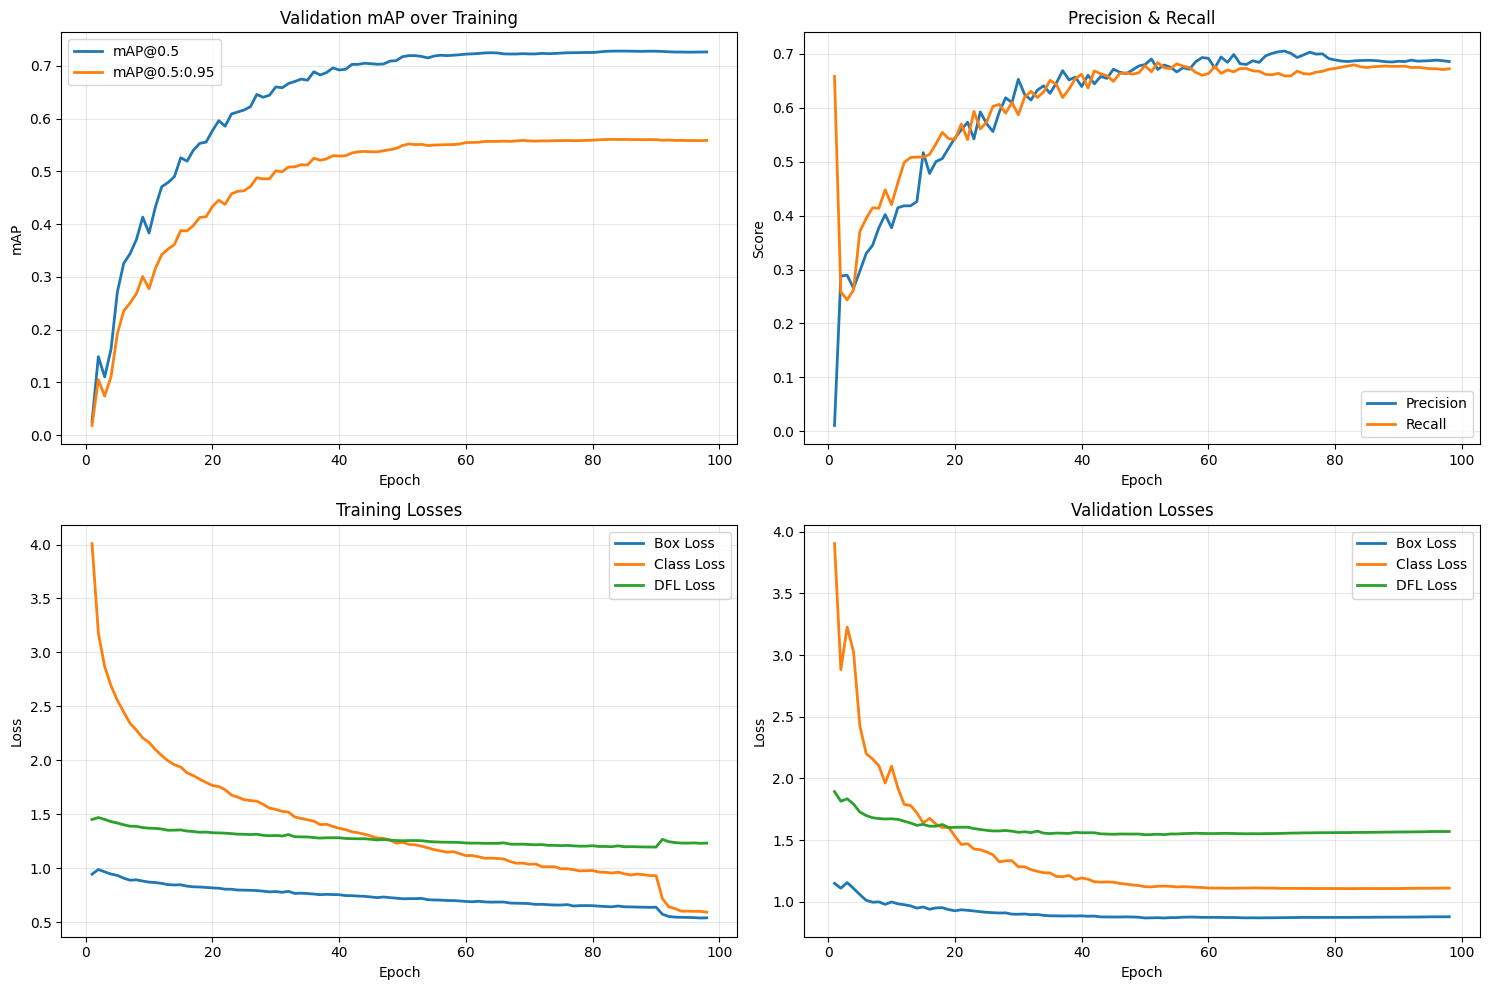

In [5]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# ============================================
# FIND YOUR TRAINING RUN
# ============================================
print("="*60)
print("CHECKING TRAINING RESULTS")
print("="*60)

# Find the most recent training run
train_dir = "./runs/detect/train/"
runs = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])

if not runs:
    print("❌ No training runs found!")
    exit(1)


run_path = "./runs/detect/train"

print(f"\nLatest training run: {latest_run}")
print(f"Location: {run_path}\n")

# ============================================
# READ TRAINING RESULTS
# ============================================
results_csv = f"{run_path}/results.csv"

if not os.path.exists(results_csv):
    print("❌ results.csv not found!")
    exit(1)

df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()  # Remove whitespace

print("="*60)
print("TRAINING SUMMARY")
print("="*60)

# Get final metrics
final_row = df.iloc[-1]

print(f"\nTraining Details:")
print(f"  Total epochs completed: {len(df)}")
print(f"  Final epoch: {int(final_row['epoch'])}")

print(f"\nFinal Metrics:")
print(f"  mAP@0.5: {final_row['metrics/mAP50(B)']:.4f} ({final_row['metrics/mAP50(B)']*100:.2f}%)")
print(f"  mAP@0.5:0.95: {final_row['metrics/mAP50-95(B)']:.4f} ({final_row['metrics/mAP50-95(B)']*100:.2f}%)")
print(f"  Precision: {final_row['metrics/precision(B)']:.4f}")
print(f"  Recall: {final_row['metrics/recall(B)']:.4f}")

print(f"\nFinal Losses:")
print(f"  Box loss: {final_row['train/box_loss']:.4f}")
print(f"  Class loss: {final_row['train/cls_loss']:.4f}")
print(f"  DFL loss: {final_row['train/dfl_loss']:.4f}")

# Find best mAP
best_idx = df['metrics/mAP50(B)'].idxmax()
best_row = df.iloc[best_idx]

print(f"\nBest Performance:")
print(f"  Best mAP@0.5: {best_row['metrics/mAP50(B)']:.4f} at epoch {int(best_row['epoch'])}")
print(f"  Best mAP@0.5:0.95: {best_row['metrics/mAP50-95(B)']:.4f}")

# ============================================
# PLOT TRAINING CURVES
# ============================================
print("\n" + "="*60)
print("GENERATING PLOTS")
print("="*60)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: mAP curves
axes[0, 0].plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP@0.5', linewidth=2)
axes[0, 0].plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP@0.5:0.95', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('mAP')
axes[0, 0].set_title('Validation mAP over Training')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Precision & Recall
axes[0, 1].plot(df['epoch'], df['metrics/precision(B)'], label='Precision', linewidth=2)
axes[0, 1].plot(df['epoch'], df['metrics/recall(B)'], label='Recall', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Score')
axes[0, 1].set_title('Precision & Recall')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Training losses
axes[1, 0].plot(df['epoch'], df['train/box_loss'], label='Box Loss', linewidth=2)
axes[1, 0].plot(df['epoch'], df['train/cls_loss'], label='Class Loss', linewidth=2)
axes[1, 0].plot(df['epoch'], df['train/dfl_loss'], label='DFL Loss', linewidth=2)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].set_title('Training Losses')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Validation losses
axes[1, 1].plot(df['epoch'], df['val/box_loss'], label='Box Loss', linewidth=2)
axes[1, 1].plot(df['epoch'], df['val/cls_loss'], label='Class Loss', linewidth=2)
axes[1, 1].plot(df['epoch'], df['val/dfl_loss'], label='DFL Loss', linewidth=2)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].set_title('Validation Losses')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_analysis.png', dpi=300, bbox_inches='tight')
print("✓ Saved: training_analysis.png")

print("\n" + "="*60)
print("RESULTS SUMMARY")
print("="*60)
print(f"\nBest model saved at: {run_path}/weights/best.pt")
print(f"Latest model saved at: {run_path}/weights/last.pt")
print(f"\nConfusion matrix: {run_path}/confusion_matrix.png")
print(f"Results plot: {run_path}/results.png")
print(f"Training analysis: training_analysis.png")
print("="*60)

In [ ]:
from ultralytics import YOLO
import os
import numpy as np

print("="*60)
print("EVALUATING MODEL ON TEST SET")
print("="*60)

# ============================================ # FIND BEST MODEL # ============================================ 
model_path = "./runs/detect/train/weights/best.pt" 

if not os.path.exists(model_path): 
    print(f"❌ Model not found at: {model_path}") 
    exit(1) 

print(f"Loading model: {model_path}\n")

# ============================================
# LOAD MODEL AND EVALUATE
# ============================================
model = YOLO(model_path)

print("Running evaluation on test set...")
print("This may take 2-5 minutes...\n")

results = model.val(
    data="data.yaml",
    split='test',           
    batch=16,
    imgsz=640,
    save_json=True,
    save_hybrid=True,
    conf=0.001,
    iou=0.6,
    plots=True,
    verbose=True
)

# ============================================
# PRINT RESULTS
# ============================================
print("\n" + "="*60)
print("TEST SET EVALUATION RESULTS")
print("="*60)

print(f"\nOverall Metrics:")
print(f"  mAP@0.5: {results.box.map50:.4f} ({results.box.map50*100:.2f}%)")
print(f"  mAP@0.5:0.95: {results.box.map:.4f} ({results.box.map*100:.2f}%)")
print(f"  Precision: {results.box.mp:.4f}")
print(f"  Recall: {results.box.mr:.4f}")

print(f"\nPer-Class Performance:")
print(f"  Classes evaluated: {len(results.box.ap50)}")
print(f"  Best class mAP@0.5: {results.box.ap50.max():.4f}")
print(f"  Worst class mAP@0.5: {results.box.ap50.min():.4f}")
print(f"  Mean class mAP@0.5: {results.box.ap50.mean():.4f}")
print(f"  Median class mAP@0.5: {np.median(results.box.ap50):.4f}")

print(f"\nInference Speed:")
print(f"  Preprocess: {results.speed['preprocess']:.2f} ms")
print(f"  Inference: {results.speed['inference']:.2f} ms")
print(f"  Postprocess: {results.speed['postprocess']:.2f} ms")
total_time = sum(results.speed.values())
print(f"  Total per image: {total_time:.2f} ms")
print(f"  FPS: {1000/total_time:.1f}")

print("\n" + "="*60)
print("PERFORMANCE ASSESSMENT")
print("="*60)

map50 = results.box.map50

if map50 >= 0.70:
    print("✓ EXCELLENT: mAP > 70% - Very strong performance!")
elif map50 >= 0.60:
    print("✓ GOOD: mAP 60-70% - Solid performance for 256 classes")
elif map50 >= 0.50:
    print("⚠ ACCEPTABLE: mAP 50-60% - Decent but could improve")
elif map50 >= 0.40:
    print("⚠ BELOW TARGET: mAP 40-50% - Consider retraining")
else:
    print("❌ POOR: mAP < 40% - Needs improvement")

print("\n" + "="*60)


EVALUATING MODEL ON TEST SET
Loading model: ./runs/detect/train/weights/best.pt

Running evaluation on test set...
This may take 2-5 minutes...

WARNING  'save_hybrid=True' will append ground truth to predictions for autolabelling.
WARNING  'save_hybrid=True' will cause incorrect mAP.

Ultralytics YOLOv8.2.97  Python-3.10.9 torch-2.4.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3070 Ti Laptop GPU, 8192MiB)
Model summary (fused): 168 layers, 3,357,389 parameters, 0 gradients, 9.7 GFLOPs


val: Scanning C:\Users\nicho\Dokumen\Projects\Food Nutrient\Number 5\new_uec_yolo_split\test\labels.cache... 2959 images, 0 backgrounds, 0 corrupt: 100%|██████████| 2959/2959 [00:00<?, ?it/s]

val: WARNING  C:\Users\nicho\Dokumen\Projects\Food Nutrient\Number 5\new_uec_yolo_split\test\images\49_86.jpg: corrupt JPEG restored and saved
val: WARNING  C:\Users\nicho\Dokumen\Projects\Food Nutrient\Number 5\new_uec_yolo_split\test\images\63_11789.jpg: corrupt JPEG restored and saved



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 185/185 [00:48<00:00,  3.80it/s]


                   all       2959       2987          1          1      0.995      0.995
               class_0         31         31          1          1      0.995      0.995
               class_1         20         20          1          1      0.995      0.995
               class_2         18         18          1          1      0.995      0.995
               class_3         19         19          1          1      0.995      0.995
               class_4         31         31          1          1      0.995      0.995
               class_5         24         24          1          1      0.995      0.995
               class_6         26         26          1          1      0.995      0.995
               class_7         21         21          1          1      0.995      0.995
               class_8         18         18          1          1      0.995      0.995
               class_9         31         32          1          1      0.995      0.995
              class_1

In [ ]:
import os
import json
from collections import Counter

print("="*60)
print("COMPLETE DIAGNOSTIC CHECK")
print("="*60)

NUM_CLASSES = 155

# ============================================
# 1. CHECK DIRECTORY STRUCTURE
# ============================================
print("\n[1] CHECKING DIRECTORY STRUCTURE")
print("-"*60)

base_dir = "./new_uec_yolo_split"

for split in ['train', 'val', 'test']:
    img_dir = f"{base_dir}/{split}/images"
    lbl_dir = f"{base_dir}/{split}/labels"
    
    if os.path.exists(img_dir):
        imgs = [f for f in os.listdir(img_dir) if f.endswith('.jpg')]
        print(f"{split} images: {len(imgs):,}")
    else:
        print(f"{split} images: ❌ DIRECTORY MISSING!")
    
    if os.path.exists(lbl_dir):
        lbls = [f for f in os.listdir(lbl_dir) if f.endswith('.txt')]
        print(f"{split} labels: {len(lbls):,}")
    else:
        print(f"{split} labels: ❌ DIRECTORY MISSING!")

# ============================================
# 2. CHECK FOR DATA LEAKAGE
# ============================================
print("\n[2] CHECKING FOR DATA LEAKAGE")
print("-"*60)

train_imgs = set(os.listdir(f"{base_dir}/train/images")) if os.path.exists(f"{base_dir}/train/images") else set()
val_imgs = set(os.listdir(f"{base_dir}/val/images")) if os.path.exists(f"{base_dir}/val/images") else set()
test_imgs = set(os.listdir(f"{base_dir}/test/images")) if os.path.exists(f"{base_dir}/test/images") else set()

train_test = train_imgs & test_imgs
train_val = train_imgs & val_imgs
val_test = val_imgs & test_imgs

print(f"Train-Test overlap: {len(train_test)}")
print(f"Train-Val overlap: {len(train_val)}")
print(f"Val-Test overlap: {len(val_test)}")

if train_test:
    print(f"\n❌ CRITICAL DATA LEAKAGE: {len(train_test)} images in both train and test!")
    print("Examples:")
    for img in list(train_test)[:5]:
        print(f"  {img}")
elif train_val:
    print(f"\n⚠️ WARNING: {len(train_val)} images in both train and val")
elif val_test:
    print(f"\n⚠️ WARNING: {len(val_test)} images in both val and test")
else:
    print("✓ No data leakage detected")

# ============================================
# 3. CHECK CLASS DISTRIBUTION IN TEST SET
# ============================================
print("\n[3] CHECKING CLASS DISTRIBUTION IN TEST SET")
print("-"*60)

test_lbl_dir = f"{base_dir}/test/labels"

if os.path.exists(test_lbl_dir):
    classes_in_test = set()
    class_counts = Counter()
    
    for label_file in os.listdir(test_lbl_dir):
        if not label_file.endswith('.txt'):
            continue
        
        with open(os.path.join(test_lbl_dir, label_file), 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    cls_id = int(parts[0])
                    classes_in_test.add(cls_id)
                    class_counts[cls_id] += 1
    
    print(f"Classes in test set: {len(classes_in_test)} / 155")
    print(f"Total test boxes: {sum(class_counts.values())}")
    
    if len(classes_in_test) < 155:
        missing = 155 - len(classes_in_test)
        print(f"\n⚠️ WARNING: {missing} classes missing from test set!")
        
        # Show which classes are missing
        all_classes = set(range(155))
        missing_classes = sorted(all_classes - classes_in_test)
        print(f"Missing class IDs: {missing_classes[:20]}...")
    else:
        print("✓ All 155 classes present in test set")
    
    # Show distribution
    print(f"\nTest set distribution:")
    print(f"  Min boxes per class: {min(class_counts.values())}")
    print(f"  Max boxes per class: {max(class_counts.values())}")
    print(f"  Mean boxes per class: {sum(class_counts.values()) / len(class_counts):.1f}")
else:
    print("❌ Test labels directory not found!")

# ============================================
# 4. CHECK data.yaml
# ============================================
print("\n[4] CHECKING data.yaml")
print("-"*60)

if os.path.exists("data.yaml"):
    print("Contents of data.yaml:")
    print("-"*40)
    with open("data.yaml", 'r') as f:
        content = f.read()
        print(content)
    print("-"*40)
    
    # Parse and check paths
    import yaml
    try:
        with open("data.yaml", 'r') as f:
            data_config = yaml.safe_load(f)
        
        print("\nParsed configuration:")
        print(f"  Path: {data_config.get('path', 'NOT SET')}")
        print(f"  Train: {data_config.get('train', 'NOT SET')}")
        print(f"  Val: {data_config.get('val', 'NOT SET')}")
        print(f"  Test: {data_config.get('test', 'NOT SET')}")
        print(f"  Classes: {data_config.get('nc', 'NOT SET')}")
        
        # Check if paths exist
        base_path = data_config.get('path', '')
        test_path = os.path.join(base_path, data_config.get('test', ''))
        
        if os.path.exists(test_path):
            test_imgs_yaml = len([f for f in os.listdir(test_path) if f.endswith('.jpg')])
            print(f"\n✓ Test path exists: {test_path}")
            print(f"  Images in path: {test_imgs_yaml}")
        else:
            print(f"\n❌ Test path does NOT exist: {test_path}")
    
    except Exception as e:
        print(f"❌ Error parsing data.yaml: {e}")
else:
    print("❌ data.yaml not found!")

# ============================================
# 5. CHECK ACTUAL EVALUATION
# ============================================
print("\n[5] CHECKING WHAT MODEL ACTUALLY EVALUATED")
print("-"*60)

# Check validation results
val_dir = "runs/detect/val"
if os.path.exists(val_dir):
    val_runs = sorted([d for d in os.listdir(val_dir) if os.path.isdir(os.path.join(val_dir, d))])
    if val_runs:
        latest_val = val_runs[-1]
        print(f"Latest validation run: {latest_val}")
        
        # Check for predictions
        pred_dir = os.path.join(val_dir, latest_val, "labels")
        if os.path.exists(pred_dir):
            pred_files = [f for f in os.listdir(pred_dir) if f.endswith('.txt')]
            print(f"Number of images evaluated: {len(pred_files)}")
            
            # Sample some prediction files to see which images
            print("\nSample evaluated images:")
            for pred_file in sorted(pred_files)[:5]:
                print(f"  {pred_file}")
        else:
            print("No prediction labels found")
    else:
        print("No validation runs found")
else:
    print("No validation directory found")

# ============================================
# 6. SUMMARY
# ============================================
print("\n" + "="*60)
print("DIAGNOSTIC SUMMARY")
print("="*60)

issues = []

if train_test:
    issues.append(f"❌ CRITICAL: {len(train_test)} images leaked from train to test")

if len(classes_in_test) < 155:
    issues.append(f"❌ CRITICAL: Only {len(classes_in_test)}/155 classes in test set")

if not os.path.exists("data.yaml"):
    issues.append("❌ data.yaml missing")

if issues:
    print("\nISSUES FOUND:")
    for issue in issues:
        print(f"  {issue}")
    print("\n🔧 FIX REQUIRED BEFORE CONTINUING")
else:
    print("\n✓ No obvious issues found")
    print("\nIf you're still seeing 99.5% mAP, the issue might be:")
    print("  - Model was trained on test data")
    print("  - Wrong model being evaluated")
    print("  - Evaluation using wrong split")

print("="*60)

COMPLETE DIAGNOSTIC CHECK

[1] CHECKING DIRECTORY STRUCTURE
------------------------------------------------------------
train images: 13,057
train labels: 13,056
val images: 2,744
val labels: 2,744
test images: 2,959
test labels: 2,959

[2] CHECKING FOR DATA LEAKAGE
------------------------------------------------------------
Train-Test overlap: 0
Train-Val overlap: 0
Val-Test overlap: 0
✓ No data leakage detected

[3] CHECKING CLASS DISTRIBUTION IN TEST SET
------------------------------------------------------------
Classes in test set: 155 / 155
Total test boxes: 2987
✓ All 155 classes present in test set

Test set distribution:
  Min boxes per class: 15
  Max boxes per class: 37
  Mean boxes per class: 19.3

[4] CHECKING data.yaml
------------------------------------------------------------
Contents of data.yaml:
----------------------------------------
path: c:\Users\nicho\Dokumen\Projects\Food Nutrient\Number 5\new_uec_yolo_split
train: train/images
val: val/images
test: test/im

In [22]:
from ultralytics import YOLO

# 1. Load your best trained weights
# Adjust path if yours is different (e.g., 'runs/detect/train/weights/best.pt')
model = YOLO('runs/detect/train/weights/best.pt')

# 2. Run validation on the 'test' split
# The split='test' argument tells YOLO to look at the 'test:' path in data.yaml
metrics = model.val(
    data='data.yaml', 
    split='test',       # Key argument!
    imgsz=640,          # Ensure this matches your training image size
    batch=16,
    conf=0.25,          # Confidence threshold for evaluation
    iou=0.6,            # NMS IoU threshold
    plots=True          # Saves confusion matrices and plots
)

# 3. Print results
print(f"Mean Average Precision @.50:.95 : {metrics.box.map}")
print(f"Mean Average Precision @.50     : {metrics.box.map50}")

Ultralytics YOLOv8.2.97  Python-3.10.9 torch-2.4.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3070 Ti Laptop GPU, 8192MiB)
Model summary (fused): 168 layers, 3,357,389 parameters, 0 gradients, 9.7 GFLOPs


val: Scanning C:\Users\nicho\Dokumen\Projects\Food Nutrient\Number 5\new_uec_yolo_split\test\labels.cache... 2959 images, 0 backgrounds, 0 corrupt: 100%|██████████| 2959/2959 [00:00<?, ?it/s]

val: WARNING  C:\Users\nicho\Dokumen\Projects\Food Nutrient\Number 5\new_uec_yolo_split\test\images\49_86.jpg: corrupt JPEG restored and saved
val: WARNING  C:\Users\nicho\Dokumen\Projects\Food Nutrient\Number 5\new_uec_yolo_split\test\images\63_11789.jpg: corrupt JPEG restored and saved



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 185/185 [00:35<00:00,  5.20it/s]


                   all       2959       2987      0.687      0.675      0.724      0.581
               class_0         31         31      0.346      0.355      0.444       0.31
               class_1         20         20        0.9        0.9      0.942       0.69
               class_2         18         18      0.705      0.667      0.699      0.562
               class_3         19         19      0.495       0.67       0.57      0.515
               class_4         31         31      0.685      0.742       0.72      0.627
               class_5         24         24      0.558      0.542      0.638      0.436
               class_6         26         26       0.56      0.733      0.618      0.422
               class_7         21         21       0.78      0.714      0.819      0.705
               class_8         18         18       0.64      0.889      0.897      0.858
               class_9         31         32      0.681      0.812      0.825      0.645
              class_1